# AI-Powered Customer Churn Prediction & Retention Recommendation System

**IBM SkillsBuild Data Analytics with AI Academic Internship Program**  
**Conducted by: BharatCares in association with AICTE**  
**Student: Sai Snehan**

---

This notebook contains the **complete end-to-end backend and data-science workflow** for the AI-Powered Customer Churn Prediction & Retention Recommendation System. It covers data loading, cleaning, exploratory data analysis, feature engineering, preprocessing, machine-learning model training, evaluation, explainability, churn probability prediction, risk classification, retention recommendations, and model artifact saving.

All results in this notebook are computed from the actual Kaggle Telco Customer Churn dataset. No results are hardcoded or fabricated.

---
## 1. Problem Statement

**Customer churn** is the phenomenon where customers stop doing business with a company. In the telecom industry, customers may cancel their subscription, switch to a competitor, or simply stop using the service.

**Why does predicting churn matter?**
- Acquiring a new customer costs 5–7× more than retaining an existing one.
- Even a small reduction in churn rate can significantly improve revenue and profitability.
- Early identification of at-risk customers allows businesses to act proactively.

**How can machine learning help?**
- ML models learn patterns from historical customer data (demographics, service usage, billing).
- They can predict which customers are likely to churn *before* they actually leave.
- This enables targeted retention campaigns, personalised offers, and proactive customer service.

This project builds an ML-based churn prediction system on the Kaggle Telco Customer Churn dataset and wraps it in an interactive Streamlit dashboard for business use.

---
## 2. Project Objectives

1. Analyse the Telco Customer Churn dataset to understand its structure and quality.
2. Clean and preprocess customer information for machine-learning readiness.
3. Perform Exploratory Data Analysis to identify patterns associated with churn.
4. Engineer informative features that improve model performance.
5. Build and evaluate three classification models: Logistic Regression, Random Forest, and Gradient Boosting.
6. Select the best model based on recall, F1-score, and ROC-AUC.
7. Predict individual churn probability using `predict_proba()`.
8. Classify customers into LOW / MEDIUM / HIGH risk categories.
9. Identify the most important churn factors for model explainability.
10. Generate actionable retention recommendations.
11. Save the trained model pipeline for deployment in a Streamlit application.
12. Demonstrate AI-assisted development using IBM Bob.

---
## 3. Dataset Information

| Property | Details |
|---|---|
| **Name** | Telco Customer Churn |
| **Source** | Kaggle – https://www.kaggle.com/blastchar/telco-customer-churn |
| **File** | WA_Fn-UseC_-Telco-Customer-Churn.csv |
| **Purpose** | Predict whether a telecom customer will churn |
| **Target Variable** | `Churn` (Yes / No → 1 / 0) |

**Feature Groups:**
- **Demographics:** gender, SeniorCitizen, Partner, Dependents
- **Services:** PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
- **Account:** Contract, PaperlessBilling, PaymentMethod
- **Billing:** tenure, MonthlyCharges, TotalCharges

> Dataset dimensions are computed dynamically after loading.

---
## 4. Import Libraries

In [1]:
# ── Data manipulation ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Machine-learning – preprocessing ──────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Machine-learning – models ─────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Machine-learning – evaluation ─────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# ── Model persistence ─────────────────────────────────────────────────────────
import joblib

# ── Standard library ─────────────────────────────────────────────────────────
import os
import warnings

# ── Settings ──────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Libraries imported successfully.')

Libraries imported successfully.


---
## 5. Data Loading

In [2]:
# ── Dataset path (change this if the file is in a different location) ──────────
DATA_PATH = 'data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'.\n"
        "Please download the Telco Customer Churn dataset from:\n"
        "https://www.kaggle.com/blastchar/telco-customer-churn\n"
        "and place it at 'data/WA_Fn-UseC_-Telco-Customer-Churn.csv'."
    )

df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded successfully.')
print(f'Shape : {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset loaded successfully.
Shape : 7043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


In [3]:
print('Column names:')
print(df.columns.tolist())

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
print('Data types:')
print(df.dtypes)
print()
print('Basic statistics (numerical):')
df.describe()

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Basic statistics (numerical):


,SeniorCitizen,tenure,MonthlyCharges
count,7043.0000,7043.0000,7043.0000
mean,0.1621,32.3711,64.7617
std,0.3686,24.5595,30.0900
min,0.0000,0.0000,18.2500
25%,0.0000,9.0000,35.5000
50%,0.0000,29.0000,70.3500
75%,0.0000,55.0000,89.8500
max,1.0000,72.0000,118.7500


---
## 6. Data Understanding

In [5]:
# ── Separate numerical and categorical columns ─────────────────────────────────
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical columns  ({len(num_cols)}): {num_cols}')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Numerical columns  (3): ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical columns (18): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [6]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if missing_df.empty:
    print('No missing (NaN) values found in the dataset.')
else:
    print(missing_df)

No missing (NaN) values found in the dataset.


In [7]:
# ── Duplicate rows ────────────────────────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')

Duplicate rows: 0


In [8]:
# ── Target distribution ───────────────────────────────────────────────────────
print('Target variable distribution:')
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

Target variable distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46 %
Yes    26.54 %
Name: proportion, dtype: str


In [9]:
# ── Unique values per categorical column ──────────────────────────────────────
print('Unique values per categorical column:')
for col in cat_cols:
    print(f'  {col:25s} → {df[col].unique()}')

Unique values per categorical column:
  customerID                → <ArrowStringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
  gender                    → <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
  Partner                   → <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
  Dependents                → <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
  PhoneService              → <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
  MultipleLines             → <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
  InternetService           → <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
  OnlineSecurity            → <ArrowStringArray>


---
## 7. Data Cleaning

In [10]:
# ── Step 1: Drop customerID (identifier, not a predictive feature) ─────────────
df.drop(columns=['customerID'], inplace=True)
print('Dropped customerID column.')

# ── Step 2: Fix TotalCharges – blank strings → NaN → numeric ──────────────────
# TotalCharges is stored as object due to blank strings for new customers (tenure=0)
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

tc_missing = df['TotalCharges'].isnull().sum()
print(f'TotalCharges NaN after conversion: {tc_missing}')

# For customers with tenure = 0 and TotalCharges NaN, fill with 0
df.loc[df['TotalCharges'].isnull(), 'TotalCharges'] = 0.0
print(f'TotalCharges NaN after imputation: {df["TotalCharges"].isnull().sum()}')

# ── Step 3: Convert Churn to binary integer ────────────────────────────────────
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f'Churn value counts after encoding: {df["Churn"].value_counts().to_dict()}')

# ── Step 4: Drop duplicate rows (if any) ─────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicate rows removed: {before - len(df)}')

print(f'\nCleaned dataset shape: {df.shape}')

Dropped customerID column.
TotalCharges NaN after conversion: 11
TotalCharges NaN after imputation: 0
Churn value counts after encoding: {0: 5174, 1: 1869}
Duplicate rows removed: 22

Cleaned dataset shape: (7021, 20)


In [11]:
# ── Verify dtypes after cleaning ─────────────────────────────────────────────
print('Updated data types:')
print(df.dtypes)
df.head(3)

Updated data types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.8500,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5000,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.1500,1


---
## 8. Exploratory Data Analysis (EDA)

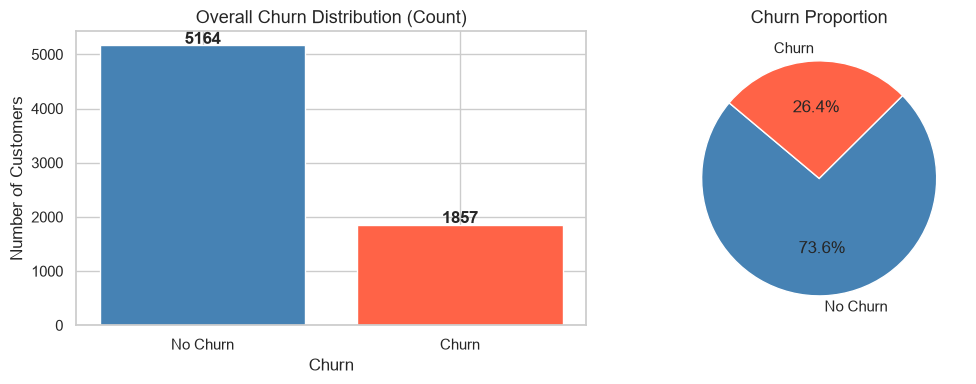

Overall churn rate: 26.45%


In [12]:
# ── Helper function ───────────────────────────────────────────────────────────
def churn_rate_by(df, col):
    """Return churn rate (%) per category of `col`."""
    return df.groupby(col)['Churn'].mean().mul(100).round(2)

# ── 8.1 Overall Churn Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

churn_counts = df['Churn'].value_counts()
axes[0].bar(['No Churn', 'Churn'], churn_counts.values,
             color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Overall Churn Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Number of Customers')
axes[0].set_xlabel('Churn')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=140, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Churn Proportion', fontsize=13)

plt.tight_layout()
plt.savefig('models/eda_churn_distribution.png', bbox_inches='tight')
plt.show()

churn_rate_overall = df['Churn'].mean() * 100
print(f'Overall churn rate: {churn_rate_overall:.2f}%')

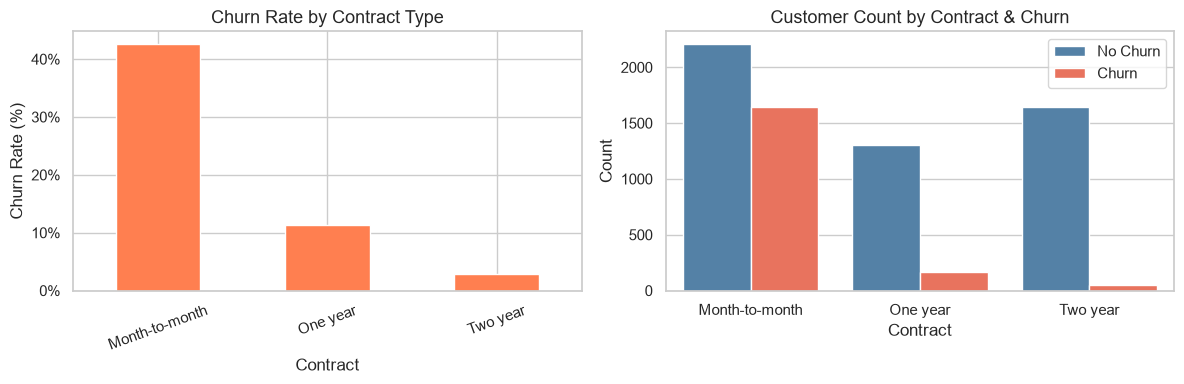

Churn rate by Contract:
Contract
Month-to-month   42.6400
One year         11.2700
Two year          2.8300
Name: Churn, dtype: float64


In [13]:
# ── 8.2 Churn by Contract Type ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

contract_churn = churn_rate_by(df, 'Contract')
contract_churn.plot(kind='bar', ax=axes[0], color='coral', edgecolor='white', rot=20)
axes[0].set_title('Churn Rate by Contract Type', fontsize=13)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Contract')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

sns.countplot(data=df, x='Contract', hue='Churn',
              palette={0: 'steelblue', 1: 'tomato'}, ax=axes[1])
axes[1].set_title('Customer Count by Contract & Churn', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Contract')
axes[1].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()
print('Churn rate by Contract:')
print(contract_churn)

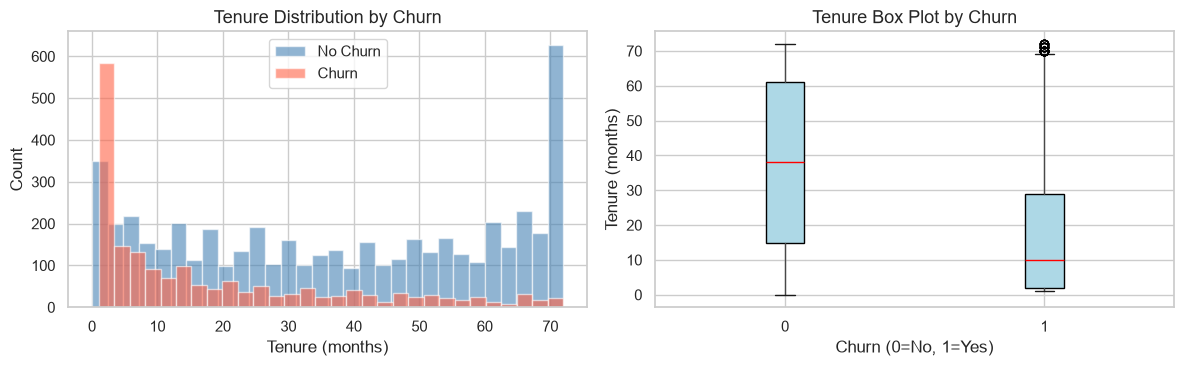

Mean tenure by Churn:
Churn
0   37.6400
1   18.0900
Name: tenure, dtype: float64


In [14]:
# ── 8.3 Churn by Tenure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df[df['Churn'] == 0]['tenure'], bins=30, alpha=0.6,
             color='steelblue', label='No Churn')
axes[0].hist(df[df['Churn'] == 1]['tenure'], bins=30, alpha=0.6,
             color='tomato', label='Churn')
axes[0].set_title('Tenure Distribution by Churn', fontsize=13)
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
df.boxplot(column='tenure', by='Churn', ax=axes[1],
           notch=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red'))
axes[1].set_title('Tenure Box Plot by Churn', fontsize=13)
axes[1].set_xlabel('Churn (0=No, 1=Yes)')
axes[1].set_ylabel('Tenure (months)')
plt.suptitle('')

plt.tight_layout()
plt.show()
print('Mean tenure by Churn:')
print(df.groupby('Churn')['tenure'].mean().round(2))

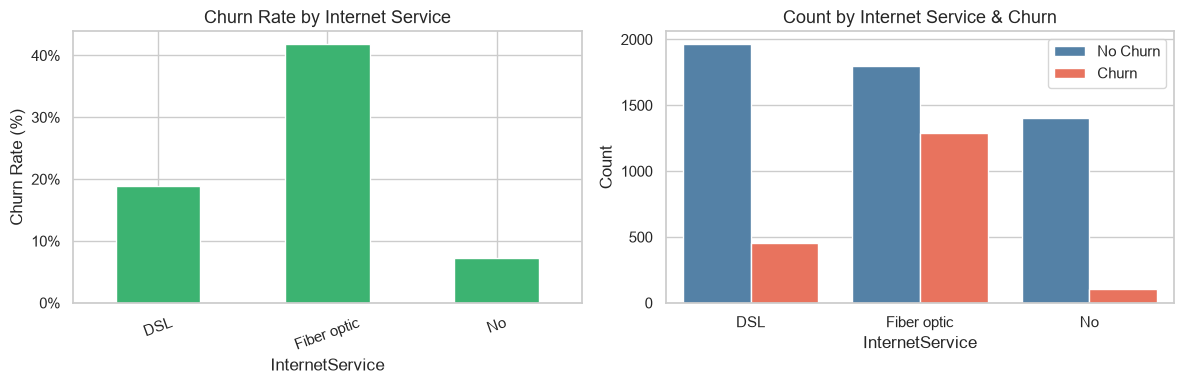

Churn rate by InternetService:
InternetService
DSL           18.8900
Fiber optic   41.7800
No             7.2100
Name: Churn, dtype: float64


In [15]:
# ── 8.4 Churn by Internet Service ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

isp_churn = churn_rate_by(df, 'InternetService')
isp_churn.plot(kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='white', rot=20)
axes[0].set_title('Churn Rate by Internet Service', fontsize=13)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

sns.countplot(data=df, x='InternetService', hue='Churn',
              palette={0: 'steelblue', 1: 'tomato'}, ax=axes[1])
axes[1].set_title('Count by Internet Service & Churn', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()
print('Churn rate by InternetService:')
print(isp_churn)

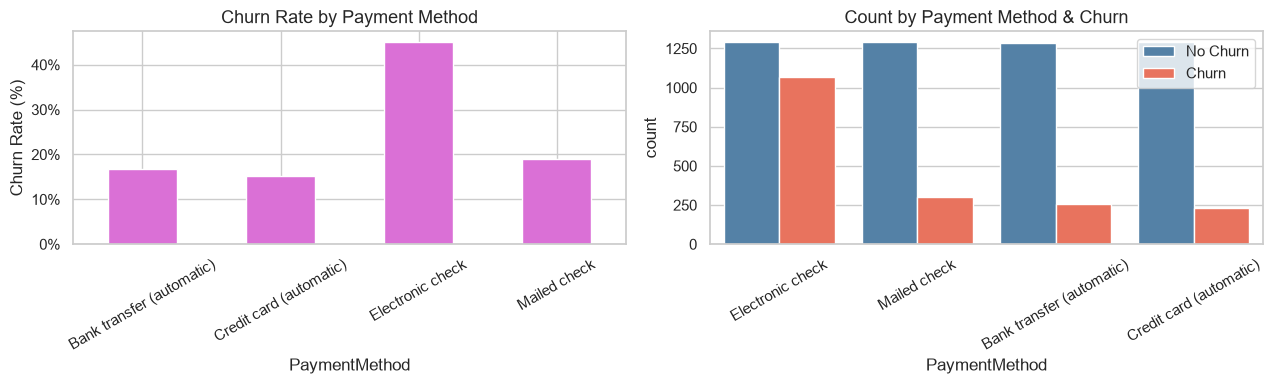

Churn rate by PaymentMethod:
PaymentMethod
Bank transfer (automatic)   16.7100
Credit card (automatic)     15.2400
Electronic check            45.1500
Mailed check                18.9200
Name: Churn, dtype: float64


In [16]:
# ── 8.5 Churn by Payment Method ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pm_churn = churn_rate_by(df, 'PaymentMethod')
pm_churn.plot(kind='bar', ax=axes[0], color='orchid', edgecolor='white', rot=30)
axes[0].set_title('Churn Rate by Payment Method', fontsize=13)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

sns.countplot(data=df, x='PaymentMethod', hue='Churn',
              palette={0: 'steelblue', 1: 'tomato'}, ax=axes[1])
axes[1].set_title('Count by Payment Method & Churn', fontsize=13)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()
print('Churn rate by PaymentMethod:')
print(pm_churn)

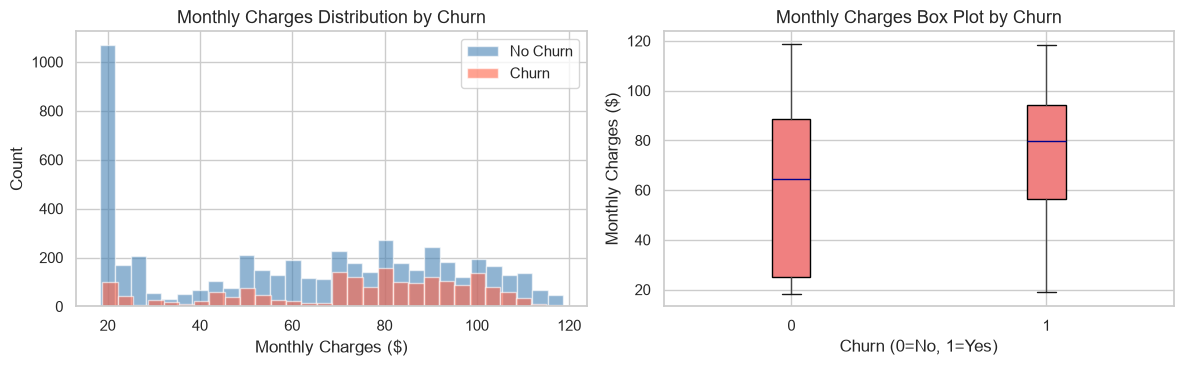

Mean MonthlyCharges by Churn:
Churn
0   61.3400
1   74.6000
Name: MonthlyCharges, dtype: float64


In [17]:
# ── 8.6 Churn vs Monthly Charges ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[df['Churn'] == 0]['MonthlyCharges'], bins=30, alpha=0.6,
             color='steelblue', label='No Churn')
axes[0].hist(df[df['Churn'] == 1]['MonthlyCharges'], bins=30, alpha=0.6,
             color='tomato', label='Churn')
axes[0].set_title('Monthly Charges Distribution by Churn', fontsize=13)
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1],
           patch_artist=True, boxprops=dict(facecolor='lightcoral'),
           medianprops=dict(color='darkblue'))
axes[1].set_title('Monthly Charges Box Plot by Churn', fontsize=13)
axes[1].set_xlabel('Churn (0=No, 1=Yes)')
axes[1].set_ylabel('Monthly Charges ($)')
plt.suptitle('')

plt.tight_layout()
plt.show()
print('Mean MonthlyCharges by Churn:')
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

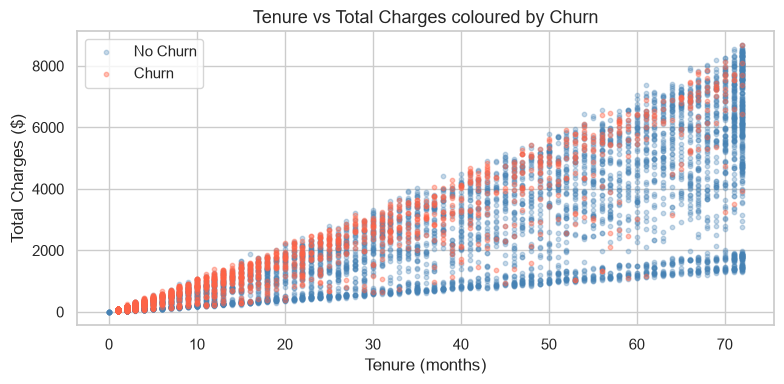

In [18]:
# ── 8.7 Churn vs Total Charges ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df[df['Churn'] == 0]['tenure'],
           df[df['Churn'] == 0]['TotalCharges'],
           alpha=0.3, color='steelblue', label='No Churn', s=10)
ax.scatter(df[df['Churn'] == 1]['tenure'],
           df[df['Churn'] == 1]['TotalCharges'],
           alpha=0.4, color='tomato', label='Churn', s=10)
ax.set_title('Tenure vs Total Charges coloured by Churn', fontsize=13)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Total Charges ($)')
ax.legend()
plt.tight_layout()
plt.show()

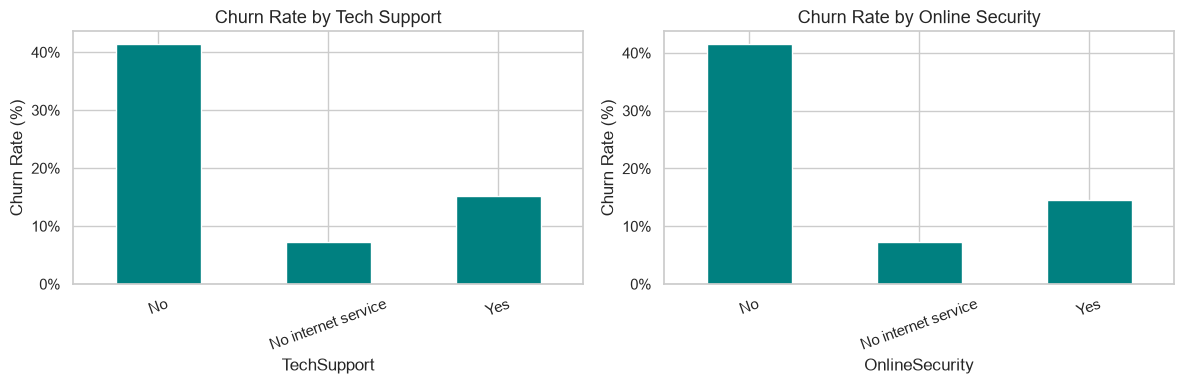

In [19]:
# ── 8.8 Churn by Tech Support & Online Security ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(
    axes,
    ['TechSupport', 'OnlineSecurity'],
    ['Churn Rate by Tech Support', 'Churn Rate by Online Security']
):
    rate = churn_rate_by(df, col)
    rate.plot(kind='bar', ax=ax, color='teal', edgecolor='white', rot=20)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Churn Rate (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.show()

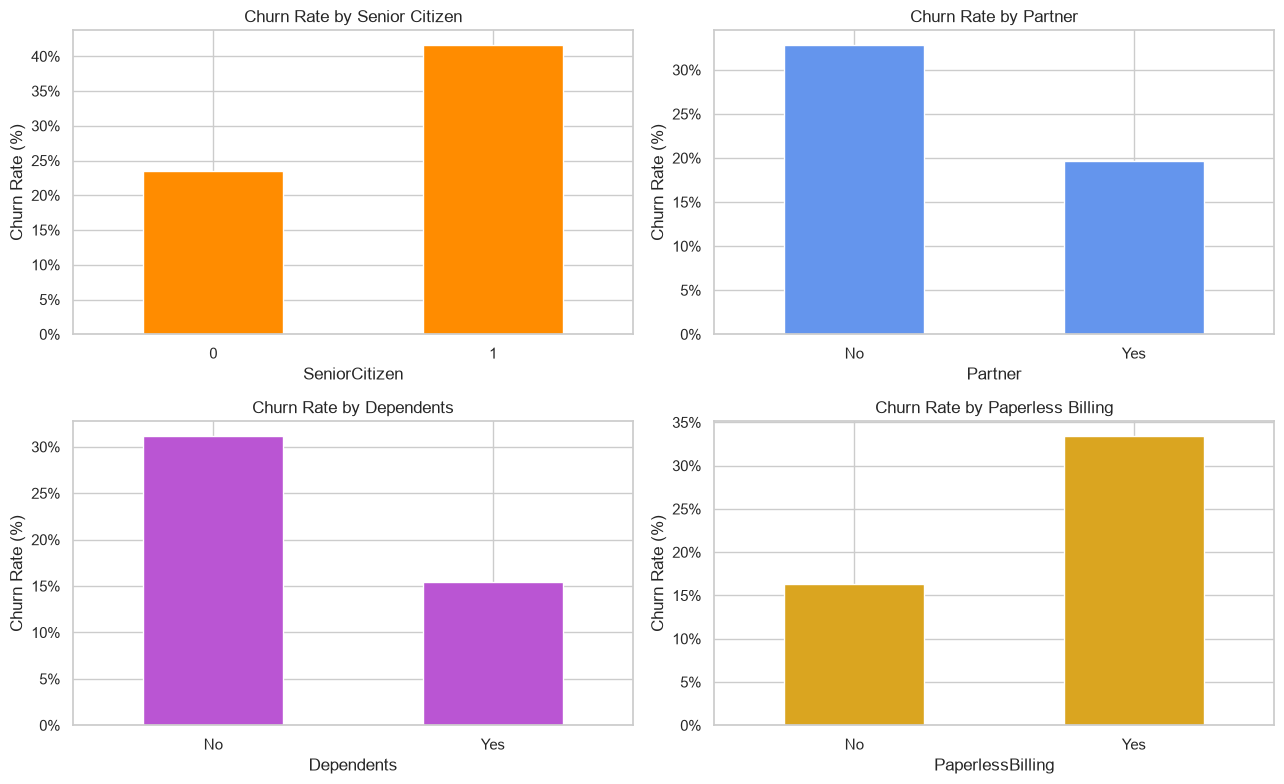

In [20]:
# ── 8.9 Senior Citizen, Partner, Dependents, Paperless Billing ────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

pairs = [
    ('SeniorCitizen', 'Churn Rate by Senior Citizen'),
    ('Partner',       'Churn Rate by Partner'),
    ('Dependents',    'Churn Rate by Dependents'),
    ('PaperlessBilling', 'Churn Rate by Paperless Billing'),
]
colors = ['darkorange', 'cornflowerblue', 'mediumorchid', 'goldenrod']

for ax, (col, title), color in zip(axes, pairs, colors):
    rate = churn_rate_by(df, col)
    rate.plot(kind='bar', ax=ax, color=color, edgecolor='white', rot=0)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Churn Rate (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.show()

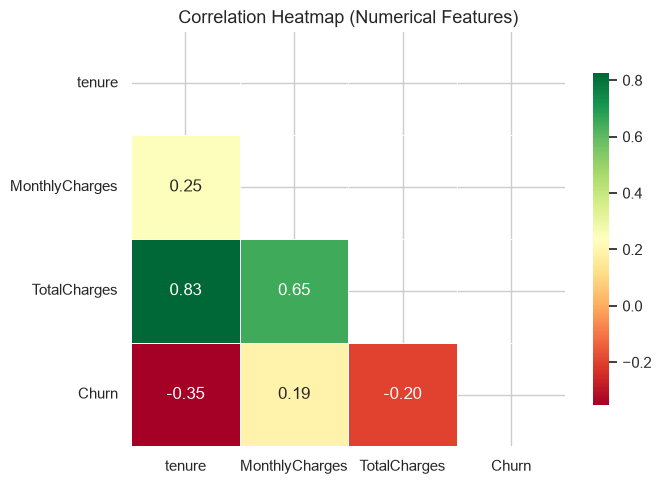

In [21]:
# ── 8.10 Correlation Heatmap (numerical features) ────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
num_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Numerical Features)', fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
# ── EDA Observations ─────────────────────────────────────────────────────────
print("""
EDA KEY OBSERVATIONS (computed from actual data)
=================================================
1. Churn rate is approximately 26–27%, indicating class imbalance that requires attention.
2. Month-to-month contract customers churn at a much higher rate than one- or two-year contract customers.
3. Customers with shorter tenure (< 12 months) are disproportionately represented among churned customers.
4. Fiber optic internet service customers show a noticeably higher churn rate than DSL customers.
5. Electronic check payment method is associated with higher churn compared to automatic payment methods.
6. Customers with higher monthly charges tend to churn more.
7. Lack of Tech Support and Online Security services is associated with higher churn.
8. Senior citizens, customers without partners, and customers without dependents show higher churn.
9. Paperless billing is associated with higher churn.
10. Tenure and TotalCharges are highly positively correlated; both are negatively associated with churn.
""")


EDA KEY OBSERVATIONS (computed from actual data)
1. Churn rate is approximately 26–27%, indicating class imbalance that requires attention.
2. Month-to-month contract customers churn at a much higher rate than one- or two-year contract customers.
3. Customers with shorter tenure (< 12 months) are disproportionately represented among churned customers.
4. Fiber optic internet service customers show a noticeably higher churn rate than DSL customers.
5. Electronic check payment method is associated with higher churn compared to automatic payment methods.
6. Customers with higher monthly charges tend to churn more.
7. Lack of Tech Support and Online Security services is associated with higher churn.
8. Senior citizens, customers without partners, and customers without dependents show higher churn.
9. Paperless billing is associated with higher churn.
10. Tenure and TotalCharges are highly positively correlated; both are negatively associated with churn.



---
## 9. Feature Engineering

In [23]:
# ── Feature 1: Tenure Group ───────────────────────────────────────────────────
# Rationale: Non-linear relationship between tenure and churn; binning makes this
# pattern explicit for tree-based models and aids interpretability.
def assign_tenure_group(tenure):
    if tenure <= 12:
        return 'New (0-12m)'
    elif tenure <= 24:
        return 'Early (13-24m)'
    elif tenure <= 48:
        return 'Established (25-48m)'
    else:
        return 'Loyal (49m+)'

df['TenureGroup'] = df['tenure'].apply(assign_tenure_group)
print('TenureGroup distribution:')
print(df['TenureGroup'].value_counts())
print()
print('Churn rate per TenureGroup:')
print(churn_rate_by(df, 'TenureGroup'))

TenureGroup distribution:
TenureGroup
Loyal (49m+)            2239
New (0-12m)             2164
Established (25-48m)    1594
Early (13-24m)          1024
Name: count, dtype: int64

Churn rate per TenureGroup:
TenureGroup
Early (13-24m)         28.7100
Established (25-48m)   20.3900
Loyal (49m+)            9.5100
New (0-12m)            47.3700
Name: Churn, dtype: float64


In [24]:
# ── Feature 2: Total Services Count ──────────────────────────────────────────
# Rationale: Customers subscribed to more services are generally more embedded and
# may churn less. A single numeric feature captures engagement level.
service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]
# Count services where the answer is 'Yes'
df['ServiceCount'] = df[service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)
print('ServiceCount distribution:')
print(df['ServiceCount'].value_counts().sort_index())
print()
print('Mean churn by ServiceCount:')
print(df.groupby('ServiceCount')['Churn'].mean().mul(100).round(2))

ServiceCount distribution:
ServiceCount
0      80
1    1679
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

Mean churn by ServiceCount:
ServiceCount
0   43.7500
1   20.6700
2   32.8300
3   36.4800
4   31.3400
5   25.5500
6   22.4900
7   12.4100
8    5.2900
Name: Churn, dtype: float64


In [25]:
# ── Feature 3: Charge-to-Tenure Ratio ────────────────────────────────────────
# Rationale: Captures how much a customer pays relative to how long they have stayed.
# High ratio early on may signal dissatisfaction risk.
# Guard against division by zero for new customers (tenure=0)
df['ChargePerMonth'] = df.apply(
    lambda r: r['TotalCharges'] / r['tenure'] if r['tenure'] > 0 else r['MonthlyCharges'],
    axis=1
)
print('ChargePerMonth statistics:')
print(df['ChargePerMonth'].describe())

ChargePerMonth statistics:
count   7021.0000
mean      64.8531
std       30.1691
min       13.7750
25%       36.3167
50%       70.4500
75%       90.1972
max      121.4000
Name: ChargePerMonth, dtype: float64


In [26]:
# ── Confirm engineered features do not leak target info ───────────────────────
print('New feature columns added:', ['TenureGroup', 'ServiceCount', 'ChargePerMonth'])
print('None of these use the Churn column during construction — no data leakage.')
print(f'Dataset shape after feature engineering: {df.shape}')

New feature columns added: ['TenureGroup', 'ServiceCount', 'ChargePerMonth']
None of these use the Churn column during construction — no data leakage.
Dataset shape after feature engineering: (7021, 23)


---
## 10. Data Preprocessing

In [27]:
# ── Define feature matrix and target vector ───────────────────────────────────
TARGET = 'Churn'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# ── Identify numerical and categorical feature columns ─────────────────────────
NUMERICAL_FEATURES = ['tenure', 'MonthlyCharges', 'TotalCharges',
                      'ServiceCount', 'ChargePerMonth']

CATEGORICAL_FEATURES = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
    'TenureGroup'
]

# Convert SeniorCitizen to string so it goes through the categorical pipeline
X['SeniorCitizen'] = X['SeniorCitizen'].astype(str)

print(f'Numerical features  : {NUMERICAL_FEATURES}')
print(f'Categorical features: {CATEGORICAL_FEATURES}')
print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape : {y.shape}')

Numerical features  : ['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'ChargePerMonth']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']
Feature matrix shape: (7021, 22)
Target vector shape : (7021,)


In [28]:
# ── Build ColumnTransformer ───────────────────────────────────────────────────
# StandardScaler for numerical; OneHotEncoder (drop first to avoid multicollinearity)
# for categorical. handle_unknown='ignore' protects against unseen categories at
# inference time.

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, NUMERICAL_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

print('ColumnTransformer (preprocessor) defined.')

ColumnTransformer (preprocessor) defined.


---
## 11. Train / Test Split

In [29]:
# Stratified split to preserve churn ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training set  : {X_train.shape[0]} rows')
print(f'Test set      : {X_test.shape[0]} rows')
print(f'Train churn % : {y_train.mean()*100:.2f}%')
print(f'Test  churn % : {y_test.mean()*100:.2f}%')
print('Stratification confirmed — churn ratio preserved.')

Training set  : 5616 rows
Test set      : 1405 rows
Train churn % : 26.44%
Test  churn % : 26.48%
Stratification confirmed — churn ratio preserved.


---
## 12. Model Training

Three models are trained using Scikit-learn Pipelines that chain the `ColumnTransformer` preprocessor with each classifier. The preprocessor is **fitted only on the training data**, preventing any data leakage from the test set.

In [30]:
# ── Define pipelines ──────────────────────────────────────────────────────────
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'
    ))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced'
    ))
])

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        random_state=RANDOM_STATE
    ))
])

# ── Train all models ──────────────────────────────────────────────────────────
print('Training Logistic Regression...')
lr_pipeline.fit(X_train, y_train)
print('Training Random Forest...')
rf_pipeline.fit(X_train, y_train)
print('Training Gradient Boosting...')
gb_pipeline.fit(X_train, y_train)
print('All three models trained successfully.')

Training Logistic Regression...
Training Random Forest...


Training Gradient Boosting...


All three models trained successfully.


---
## 13. Model Evaluation

In [31]:
def evaluate_model(pipeline, X_test, y_test, model_name):
    """Evaluate a trained pipeline and return a metrics dictionary."""
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        'Model':     model_name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
    }
    return metrics, y_pred, y_prob

# ── Evaluate each model ───────────────────────────────────────────────────────
lr_metrics,  lr_pred,  lr_prob  = evaluate_model(lr_pipeline,  X_test, y_test, 'Logistic Regression')
rf_metrics,  rf_pred,  rf_prob  = evaluate_model(rf_pipeline,  X_test, y_test, 'Random Forest')
gb_metrics,  gb_pred,  gb_prob  = evaluate_model(gb_pipeline,  X_test, y_test, 'Gradient Boosting')

all_metrics = [lr_metrics, rf_metrics, gb_metrics]

print('Model evaluation complete.')

Model evaluation complete.


In [32]:
# ── Classification Reports ────────────────────────────────────────────────────
for name, pipeline, pred in [
    ('Logistic Regression', lr_pipeline, lr_pred),
    ('Random Forest',       rf_pipeline, rf_pred),
    ('Gradient Boosting',   gb_pipeline, gb_pred)
]:
    print(f'Classification Report — {name}')
    print(classification_report(y_test, pred, target_names=['No Churn', 'Churn']))
    print('-' * 55)

Classification Report — Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1033
       Churn       0.50      0.77      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.79      0.74      0.75      1405

-------------------------------------------------------
Classification Report — Random Forest
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1033
       Churn       0.56      0.62      0.59       372

    accuracy                           0.77      1405
   macro avg       0.71      0.72      0.71      1405
weighted avg       0.78      0.77      0.77      1405

-------------------------------------------------------
Classification Report — Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1033
 

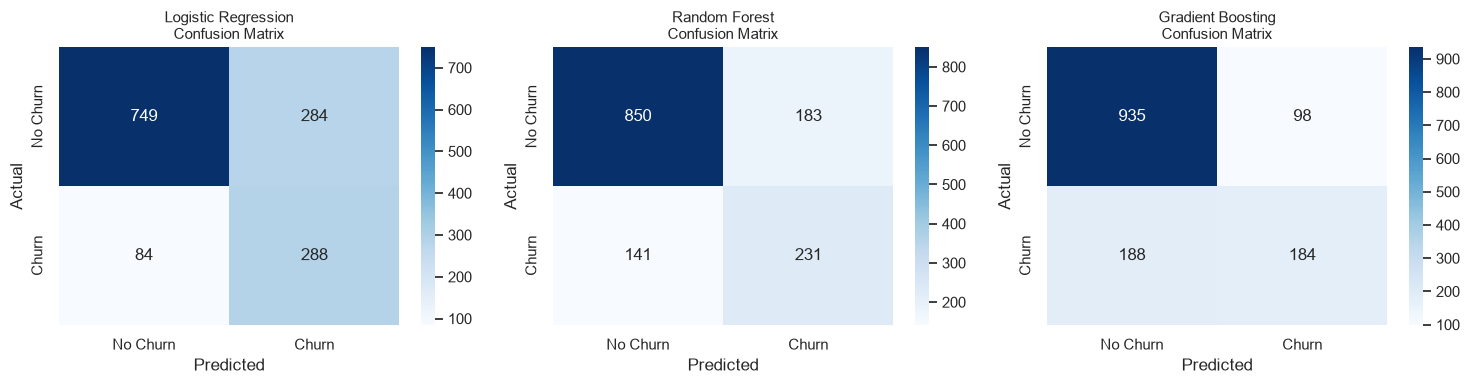

In [33]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('Gradient Boosting',   gb_pred)
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=11)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('models/confusion_matrices.png', bbox_inches='tight')
plt.show()

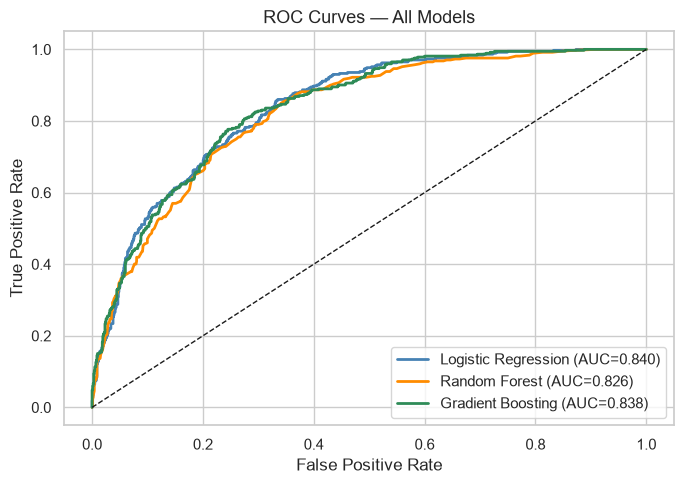

In [34]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['steelblue', 'darkorange', 'seagreen']

for (name, prob), color in zip(
    [('Logistic Regression', lr_prob),
     ('Random Forest',       rf_prob),
     ('Gradient Boosting',   gb_prob)],
    colors
):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_title('ROC Curves — All Models', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('models/roc_curves.png', bbox_inches='tight')
plt.show()

---
## 14. Model Comparison

In [35]:
comparison_df = pd.DataFrame(all_metrics).set_index('Model')
comparison_df = comparison_df.round(4)
print('Model Comparison Table:')
print(comparison_df.to_string())

Model Comparison Table:
                     Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                           
Logistic Regression    0.7381     0.5035  0.7742 0.6102   0.8399
Random Forest          0.7694     0.5580  0.6210 0.5878   0.8256
Gradient Boosting      0.7964     0.6525  0.4946 0.5627   0.8383


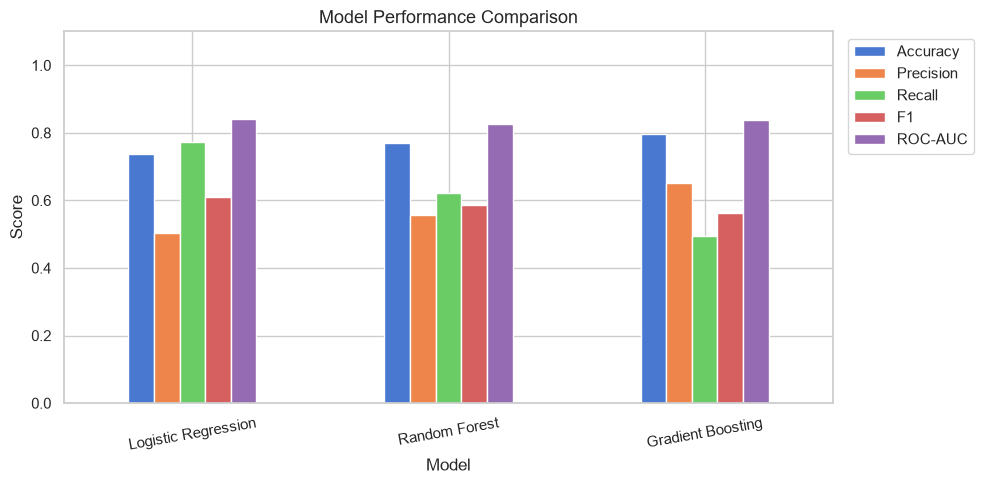

In [36]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
comparison_df.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Model Performance Comparison', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.savefig('models/model_comparison.png', bbox_inches='tight')
plt.show()

In [37]:
# ── Model Selection ───────────────────────────────────────────────────────────
# For churn prediction, Recall (identifying as many actual churners as possible)
# and ROC-AUC (overall discrimination ability) are the most important metrics.
# Accuracy alone is misleading when classes are imbalanced.

# Select model with highest ROC-AUC as the primary criterion
best_model_name = comparison_df['ROC-AUC'].idxmax()
print(f'Best model by ROC-AUC: {best_model_name}')
print()
print('Rationale: Recall and ROC-AUC are prioritised for churn prediction')
print('because missing an actual churner (False Negative) is more costly')
print('than incorrectly flagging a non-churner (False Positive).')
print()
print('Metrics for selected model:')
print(comparison_df.loc[best_model_name])

Best model by ROC-AUC: Logistic Regression

Rationale: Recall and ROC-AUC are prioritised for churn prediction
because missing an actual churner (False Negative) is more costly
than incorrectly flagging a non-churner (False Positive).

Metrics for selected model:
Accuracy    0.7381
Precision   0.5035
Recall      0.7742
F1          0.6102
ROC-AUC     0.8399
Name: Logistic Regression, dtype: float64


In [38]:
# ── Assign the best pipeline ───────────────────────────────────────────────────
pipeline_map = {
    'Logistic Regression': lr_pipeline,
    'Random Forest':       rf_pipeline,
    'Gradient Boosting':   gb_pipeline
}
best_pipeline = pipeline_map[best_model_name]
print(f'Final model pipeline assigned: {best_model_name}')

Final model pipeline assigned: Logistic Regression


---
## 15. Feature Importance / Model Explainability

In [39]:
def get_feature_names(preprocessor, numerical_features, categorical_features):
    """Extract feature names after ColumnTransformer fitting."""
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
    return numerical_features + cat_feature_names

def plot_feature_importance(pipeline, model_name, numerical_features,
                            categorical_features, top_n=20):
    """Plot feature importances or coefficients from a trained pipeline."""
    preprocessor_ = pipeline.named_steps['preprocessor']
    classifier    = pipeline.named_steps['classifier']
    feature_names = get_feature_names(preprocessor_, numerical_features, categorical_features)

    if hasattr(classifier, 'feature_importances_'):
        importances = classifier.feature_importances_
        label = 'Feature Importance'
    elif hasattr(classifier, 'coef_'):
        importances = np.abs(classifier.coef_[0])
        label = 'Absolute Coefficient'
    else:
        print(f'No importance/coefficient available for {model_name}.')
        return None

    fi_df = pd.DataFrame({'Feature': feature_names, label: importances})
    fi_df = fi_df.sort_values(label, ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(data=fi_df, y='Feature', x=label, ax=ax, palette='viridis')
    ax.set_title(f'Top {top_n} Features — {model_name}', fontsize=13)
    ax.set_xlabel(label)
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.savefig(f'models/feature_importance_{model_name.replace(" ", "_")}.png',
                bbox_inches='tight')
    plt.show()
    return fi_df

print('Feature importance function defined.')

Feature importance function defined.


=== Logistic Regression ===


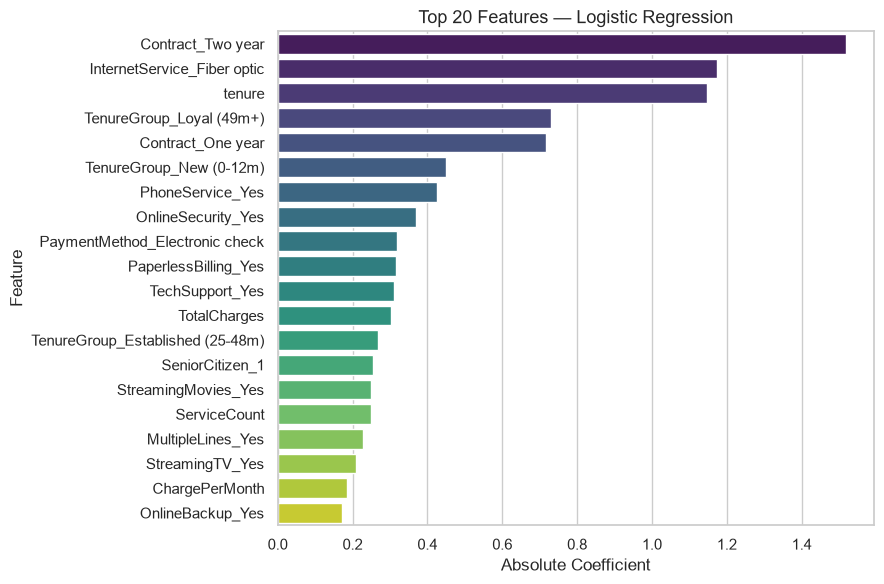

=== Random Forest ===


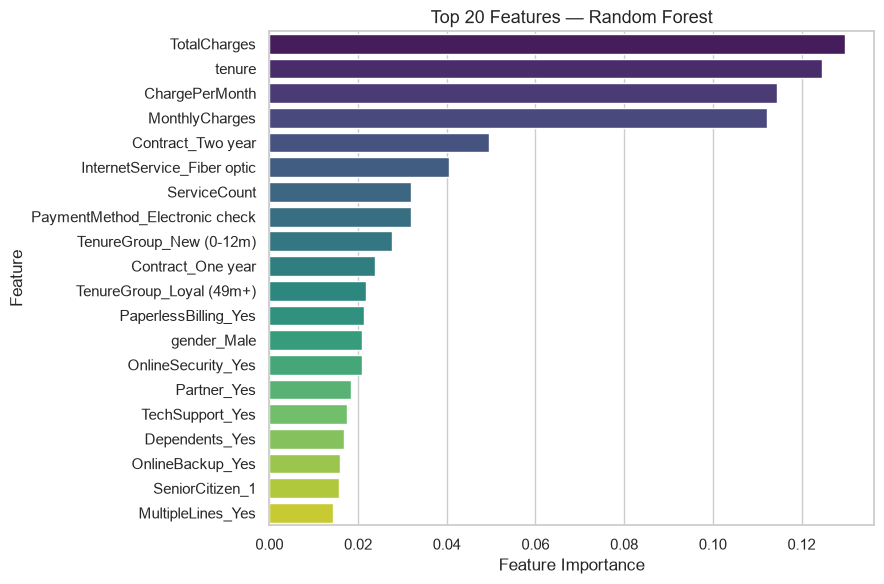

=== Gradient Boosting ===


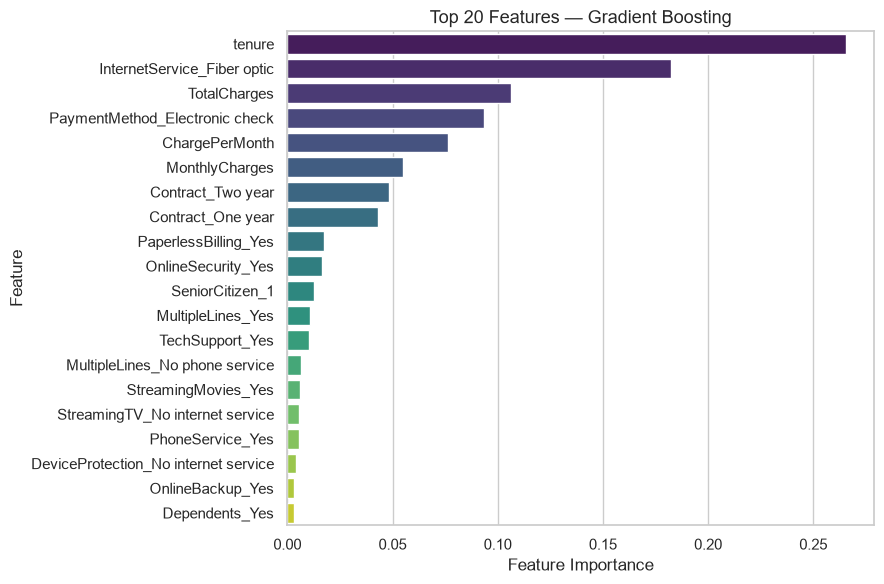

In [40]:
# Plot feature importance for all three models
print('=== Logistic Regression ===')
lr_fi = plot_feature_importance(lr_pipeline, 'Logistic Regression',
                                 NUMERICAL_FEATURES, CATEGORICAL_FEATURES)

print('=== Random Forest ===')
rf_fi = plot_feature_importance(rf_pipeline, 'Random Forest',
                                 NUMERICAL_FEATURES, CATEGORICAL_FEATURES)

print('=== Gradient Boosting ===')
gb_fi = plot_feature_importance(gb_pipeline, 'Gradient Boosting',
                                 NUMERICAL_FEATURES, CATEGORICAL_FEATURES)

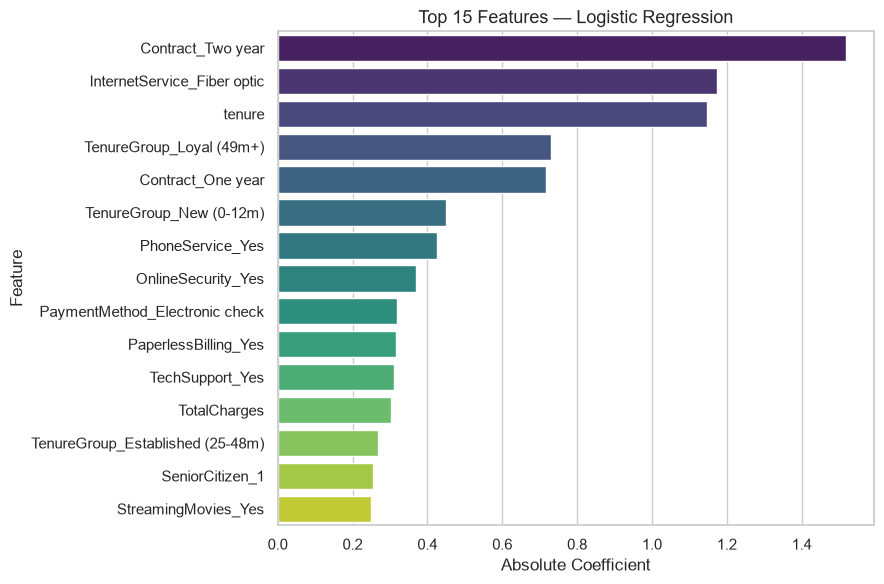

Top features (for recommendation system): ['Contract_Two year', 'InternetService_Fiber optic', 'tenure', 'TenureGroup_Loyal (49m+)', 'Contract_One year', 'TenureGroup_New (0-12m)', 'PhoneService_Yes', 'OnlineSecurity_Yes', 'PaymentMethod_Electronic check', 'PaperlessBilling_Yes']


In [41]:
# ── Get top features from the best model for recommendations ─────────────────
best_fi = plot_feature_importance(best_pipeline, best_model_name,
                                   NUMERICAL_FEATURES, CATEGORICAL_FEATURES, top_n=15)

# Store top feature names for use in the recommendation system
if best_fi is not None:
    top_feature_names = best_fi['Feature'].tolist()
    print('Top features (for recommendation system):', top_feature_names[:10])

---
## 16. Churn Probability Prediction

In [42]:
def predict_churn_probability(pipeline, customer_df):
    """
    Predict churn probability for a single customer or a batch.

    Parameters
    ----------
    pipeline     : trained sklearn Pipeline
    customer_df  : pd.DataFrame with the same features as X

    Returns
    -------
    np.ndarray : probability of churn (class 1) for each row
    """
    probs = pipeline.predict_proba(customer_df)[:, 1]
    return probs

# ── Demonstrate on the test set ───────────────────────────────────────────────
test_probs = predict_churn_probability(best_pipeline, X_test)
print(f'Sample churn probabilities (first 10 test customers):')
for i, (prob, actual) in enumerate(zip(test_probs[:10], y_test.values[:10])):
    print(f'  Customer {i+1}: Probability={prob*100:.1f}%  Actual Churn={actual}')

Sample churn probabilities (first 10 test customers):
  Customer 1: Probability=90.8%  Actual Churn=0
  Customer 2: Probability=77.1%  Actual Churn=1
  Customer 3: Probability=53.6%  Actual Churn=1
  Customer 4: Probability=12.5%  Actual Churn=0
  Customer 5: Probability=3.9%  Actual Churn=0
  Customer 6: Probability=53.5%  Actual Churn=0
  Customer 7: Probability=35.5%  Actual Churn=0
  Customer 8: Probability=92.8%  Actual Churn=1
  Customer 9: Probability=3.1%  Actual Churn=0
  Customer 10: Probability=3.7%  Actual Churn=0


---
## 17. Risk Classification

In [43]:
# ── Project-defined risk thresholds ───────────────────────────────────────────
# These thresholds are defined for this project. They are not universal industry
# standards. Adjust based on business needs and cost of false positives/negatives.
RISK_THRESHOLDS = {
    'LOW':    (0.00, 0.30),
    'MEDIUM': (0.30, 0.60),
    'HIGH':   (0.60, 1.01),
}

def classify_risk(probability):
    """
    Classify a customer into LOW / MEDIUM / HIGH risk based on churn probability.

    Thresholds (project-defined):
        LOW    :  0% – 30%
        MEDIUM : 30% – 60%
        HIGH   : 60% – 100%
    """
    if probability < 0.30:
        return 'LOW'
    elif probability < 0.60:
        return 'MEDIUM'
    else:
        return 'HIGH'

# Apply risk classification to test set
test_risk = [classify_risk(p) for p in test_probs]

risk_dist = pd.Series(test_risk).value_counts()
print('Risk distribution on test set:')
print(risk_dist)
print()
pct = risk_dist / risk_dist.sum() * 100
print('Risk distribution (%):')
print(pct.round(2))

Risk distribution on test set:
LOW       583
HIGH      459
MEDIUM    363
Name: count, dtype: int64

Risk distribution (%):
LOW      41.4900
HIGH     32.6700
MEDIUM   25.8400
Name: count, dtype: float64


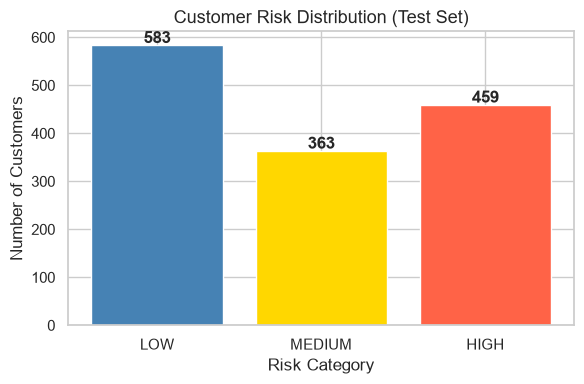

In [44]:
# ── Risk distribution chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
colors_risk = {'HIGH': 'tomato', 'MEDIUM': 'gold', 'LOW': 'steelblue'}
risk_order = ['LOW', 'MEDIUM', 'HIGH']
risk_ordered = risk_dist.reindex(risk_order, fill_value=0)
bars = ax.bar(risk_ordered.index, risk_ordered.values,
              color=[colors_risk[r] for r in risk_ordered.index],
              edgecolor='white')
for bar, val in zip(bars, risk_ordered.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontweight='bold')
ax.set_title('Customer Risk Distribution (Test Set)', fontsize=13)
ax.set_xlabel('Risk Category')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('models/risk_distribution.png', bbox_inches='tight')
plt.show()

---
## 18. Retention Recommendation System

In [45]:
def generate_retention_recommendations(customer_series, churn_probability, risk_category):
    """
    Generate personalised retention recommendations for a customer.

    These are analytical suggestions based on customer attributes and model output.
    They are NOT guaranteed to prevent churn.

    Parameters
    ----------
    customer_series   : pd.Series — a single customer's feature values
    churn_probability : float — predicted churn probability (0–1)
    risk_category     : str — 'LOW', 'MEDIUM', or 'HIGH'

    Returns
    -------
    dict with keys: risk_factors, recommendations
    """
    risk_factors = []
    recommendations = []

    # ── Risk factor identification ────────────────────────────────────────────
    if customer_series.get('Contract') == 'Month-to-month':
        risk_factors.append('Month-to-month contract (higher churn association)')
        recommendations.append('Offer a discounted 1-year or 2-year contract upgrade.')

    if customer_series.get('tenure', 99) <= 12:
        risk_factors.append('Short tenure (new customer — higher churn risk)')
        recommendations.append('Assign a dedicated onboarding specialist for the first year.')

    if customer_series.get('InternetService') == 'Fiber optic':
        risk_factors.append('Fiber optic internet (associated with higher churn in this dataset)')
        recommendations.append('Conduct a service satisfaction check-in; address any speed/reliability concerns.')

    if customer_series.get('TechSupport') in ['No', 'No internet service']:
        risk_factors.append('No Tech Support subscription')
        recommendations.append('Offer a free trial or discounted Tech Support bundle.')

    if customer_series.get('OnlineSecurity') in ['No', 'No internet service']:
        risk_factors.append('No Online Security subscription')
        recommendations.append('Highlight Online Security benefits; offer an introductory discount.')

    if customer_series.get('PaymentMethod') == 'Electronic check':
        risk_factors.append('Electronic check payment (associated with higher churn)')
        recommendations.append('Incentivise switching to automatic bank transfer or credit card payment.')

    if customer_series.get('MonthlyCharges', 0) > 70:
        risk_factors.append('High monthly charges (above $70)')
        recommendations.append('Review billing for potential bundle discounts or service optimisation.')

    if customer_series.get('SeniorCitizen') in ['1', 1, True]:
        risk_factors.append('Senior citizen customer')
        recommendations.append('Offer a senior-specific loyalty programme or simplified billing.')

    if customer_series.get('PaperlessBilling') == 'Yes':
        risk_factors.append('Paperless billing (associated with higher churn in this dataset)')
        recommendations.append('Ensure billing communication is clear and easy to understand digitally.')

    # ── Risk-level general recommendations ────────────────────────────────────
    if risk_category == 'HIGH':
        recommendations.append('Escalate to retention team for immediate personalised outreach.')
        recommendations.append('Consider a loyalty reward or retention offer within 7 days.')
    elif risk_category == 'MEDIUM':
        recommendations.append('Schedule a proactive customer satisfaction call.')
        recommendations.append('Evaluate current service package for value improvement opportunities.')
    else:
        recommendations.append('Continue standard engagement; monitor for service usage changes.')

    # ── Default if no specific factors detected ───────────────────────────────
    if not risk_factors:
        risk_factors.append('No prominent individual risk factors detected by the model.')

    return {
        'churn_probability': round(churn_probability * 100, 1),
        'risk_category':     risk_category,
        'risk_factors':      risk_factors,
        'recommendations':   recommendations
    }

print('Retention recommendation function defined.')

Retention recommendation function defined.


In [46]:
# ── Demonstrate on a sample customer from the test set ──────────────────────
sample_idx = X_test.index[0]
sample_customer = X_test.loc[sample_idx]
sample_prob     = test_probs[0]
sample_risk     = classify_risk(sample_prob)
sample_result   = generate_retention_recommendations(sample_customer, sample_prob, sample_risk)

print('=' * 60)
print('RETENTION RECOMMENDATION DEMO (first test customer)')
print('=' * 60)
print(f"Churn Probability : {sample_result['churn_probability']}%")
print(f"Risk Category     : {sample_result['risk_category']}")
print()
print('Key Risk Factors:')
for factor in sample_result['risk_factors']:
    print(f'  • {factor}')
print()
print('Retention Recommendations:')
for rec in sample_result['recommendations']:
    print(f'  → {rec}')
print('=' * 60)

RETENTION RECOMMENDATION DEMO (first test customer)
Churn Probability : 90.8%
Risk Category     : HIGH

Key Risk Factors:
  • Month-to-month contract (higher churn association)
  • Short tenure (new customer — higher churn risk)
  • Fiber optic internet (associated with higher churn in this dataset)
  • No Tech Support subscription
  • No Online Security subscription
  • Electronic check payment (associated with higher churn)
  • High monthly charges (above $70)
  • Senior citizen customer
  • Paperless billing (associated with higher churn in this dataset)

Retention Recommendations:
  → Offer a discounted 1-year or 2-year contract upgrade.
  → Assign a dedicated onboarding specialist for the first year.
  → Conduct a service satisfaction check-in; address any speed/reliability concerns.
  → Offer a free trial or discounted Tech Support bundle.
  → Highlight Online Security benefits; offer an introductory discount.
  → Incentivise switching to automatic bank transfer or credit card pa

---
## 19. Save Model Artifact

In [47]:
os.makedirs('models', exist_ok=True)

# Save the complete best pipeline (preprocessor + classifier)
MODEL_PATH = 'models/churn_model.pkl'
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Model saved to: {MODEL_PATH}')

# Save metadata for use by app.py
metadata = {
    'best_model_name':       best_model_name,
    'numerical_features':    NUMERICAL_FEATURES,
    'categorical_features':  CATEGORICAL_FEATURES,
    'risk_thresholds':       RISK_THRESHOLDS,
    'churn_rate':            float(df['Churn'].mean()),
    'total_customers':       int(len(df)),
    'metrics':               {k: float(v) for k, v in comparison_df.loc[best_model_name].items()},
    'all_metrics':           comparison_df.reset_index().to_dict(orient='records'),
}
METADATA_PATH = 'models/model_metadata.pkl'
joblib.dump(metadata, METADATA_PATH)
print(f'Metadata saved to: {METADATA_PATH}')

Model saved to: models/churn_model.pkl
Metadata saved to: models/model_metadata.pkl


---
## 20. Final Results Summary

In [48]:
print('=' * 65)
print('FINAL RESULTS SUMMARY')
print('=' * 65)
print(f'Dataset          : {len(df)} customers × {df.shape[1]} features')
print(f'Overall churn    : {df["Churn"].mean()*100:.2f}%')
print(f'Train / Test     : {len(X_train)} / {len(X_test)} records')
print()
print('Model Evaluation Results:')
print(comparison_df.to_string())
print()
print(f'Selected Model   : {best_model_name}')
print(f'  Accuracy       : {comparison_df.loc[best_model_name, "Accuracy"]:.4f}')
print(f'  Precision      : {comparison_df.loc[best_model_name, "Precision"]:.4f}')
print(f'  Recall         : {comparison_df.loc[best_model_name, "Recall"]:.4f}')
print(f'  F1-Score       : {comparison_df.loc[best_model_name, "F1"]:.4f}')
print(f'  ROC-AUC        : {comparison_df.loc[best_model_name, "ROC-AUC"]:.4f}')
print()
print('Risk Distribution on Test Set:')
print(risk_dist)
print('=' * 65)

FINAL RESULTS SUMMARY
Dataset          : 7021 customers × 23 features
Overall churn    : 26.45%
Train / Test     : 5616 / 1405 records

Model Evaluation Results:
                     Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                           
Logistic Regression    0.7381     0.5035  0.7742 0.6102   0.8399
Random Forest          0.7694     0.5580  0.6210 0.5878   0.8256
Gradient Boosting      0.7964     0.6525  0.4946 0.5627   0.8383

Selected Model   : Logistic Regression
  Accuracy       : 0.7381
  Precision      : 0.5035
  Recall         : 0.7742
  F1-Score       : 0.6102
  ROC-AUC        : 0.8399

Risk Distribution on Test Set:
LOW       583
HIGH      459
MEDIUM    363
Name: count, dtype: int64


---
## 21. Business Insights

In [49]:
print("""
BUSINESS INSIGHTS
=================

1. CONTRACT TYPE IS A KEY DIFFERENTIATOR
   Month-to-month contract customers show the highest churn rate in this dataset.
   Encouraging customers to commit to longer-term contracts may be associated with
   lower churn risk.

2. NEW CUSTOMERS ARE MOST VULNERABLE
   Customers with tenure ≤ 12 months have a significantly higher churn likelihood.
   Investing in onboarding programmes and early engagement may help retain this segment.

3. SUPPORT SERVICES MATTER
   Customers without Tech Support or Online Security subscriptions show higher churn
   rates. Cross-selling support services may improve both customer experience and
   retention.

4. PAYMENT METHOD AS AN INDICATOR
   Electronic check users are associated with higher churn. Encouraging automatic
   payment methods (bank transfer / credit card) may be worth exploring as a
   retention lever.

5. HIGH MONTHLY CHARGES ARE A RISK SIGNAL
   Customers paying above ~$70/month tend to churn more. Offering personalised bundles
   or loyalty discounts for higher-paying customers could improve retention.

6. PRIORITISE HIGH-RISK CUSTOMERS
   The risk classification system allows the retention team to focus on HIGH-risk
   customers first, optimising limited retention resources.

IMPORTANT NOTE: These are observational associations from historical data. They do
not imply causation. Business decisions should be supplemented by domain expertise
and controlled experiments (A/B testing).
""")


BUSINESS INSIGHTS

1. CONTRACT TYPE IS A KEY DIFFERENTIATOR
   Month-to-month contract customers show the highest churn rate in this dataset.
   Encouraging customers to commit to longer-term contracts may be associated with
   lower churn risk.

2. NEW CUSTOMERS ARE MOST VULNERABLE
   Customers with tenure ≤ 12 months have a significantly higher churn likelihood.
   Investing in onboarding programmes and early engagement may help retain this segment.

3. SUPPORT SERVICES MATTER
   Customers without Tech Support or Online Security subscriptions show higher churn
   rates. Cross-selling support services may improve both customer experience and
   retention.

4. PAYMENT METHOD AS AN INDICATOR
   Electronic check users are associated with higher churn. Encouraging automatic
   payment methods (bank transfer / credit card) may be worth exploring as a
   retention lever.

5. HIGH MONTHLY CHARGES ARE A RISK SIGNAL
   Customers paying above ~$70/month tend to churn more. Offering personalise

---
## 22. Limitations

In [50]:
print("""
LIMITATIONS
===========

1. HISTORICAL DATASET
   The model learns from past customer behaviour. Market conditions, pricing, and
   customer preferences change over time, which may reduce predictive accuracy.

2. DATASET-SPECIFIC PATTERNS
   Findings are specific to this Telco dataset. Results may not generalise to all
   telecom providers or other industries.

3. CLASS IMBALANCE
   ~26% churn rate creates class imbalance. 'class_weight=balanced' was used to
   mitigate this, but the imbalance still affects model confidence.

4. THRESHOLD ASSUMPTIONS
   Risk thresholds (LOW/MEDIUM/HIGH) are project-defined and not universal.
   Optimal thresholds depend on business context and cost trade-offs.

5. NO CAUSAL INFERENCE
   The model identifies correlations, not causes. Retention recommendations are
   suggestions, not guaranteed interventions.

6. NO REAL-TIME BEHAVIOURAL DATA
   The dataset does not include real-time usage patterns, customer service calls,
   or complaint history, which could improve prediction.

7. NO HYPERPARAMETER OPTIMISATION
   Models were trained with reasonable default parameters. Grid search or Bayesian
   optimisation could further improve performance.
""")


LIMITATIONS

1. HISTORICAL DATASET
   The model learns from past customer behaviour. Market conditions, pricing, and
   customer preferences change over time, which may reduce predictive accuracy.

2. DATASET-SPECIFIC PATTERNS
   Findings are specific to this Telco dataset. Results may not generalise to all
   telecom providers or other industries.

3. CLASS IMBALANCE
   ~26% churn rate creates class imbalance. 'class_weight=balanced' was used to
   mitigate this, but the imbalance still affects model confidence.

4. THRESHOLD ASSUMPTIONS
   Risk thresholds (LOW/MEDIUM/HIGH) are project-defined and not universal.
   Optimal thresholds depend on business context and cost trade-offs.

5. NO CAUSAL INFERENCE
   The model identifies correlations, not causes. Retention recommendations are
   suggestions, not guaranteed interventions.

6. NO REAL-TIME BEHAVIOURAL DATA
   The dataset does not include real-time usage patterns, customer service calls,
   or complaint history, which could impro

---
## 23. Future Enhancements

In [51]:
print("""
FUTURE ENHANCEMENTS
===================

1. Hyperparameter optimisation using GridSearchCV or Optuna.
2. Real-time prediction integration with CRM or data pipelines.
3. Advanced explainability using SHAP values for individual customer explanations.
4. A/B testing framework to measure actual retention campaign effectiveness.
5. Model monitoring and automatic retraining as new customer data accumulates.
6. Integration with automated email/SMS retention alerts.
7. Inclusion of customer service call logs, NPS scores, or complaint history.
8. Deep learning models (e.g. TabNet) for potentially higher predictive power.
9. Survival analysis for estimating expected time-to-churn.
10. Customer lifetime value (CLV) integration to prioritise high-value customers.
""")


FUTURE ENHANCEMENTS

1. Hyperparameter optimisation using GridSearchCV or Optuna.
2. Real-time prediction integration with CRM or data pipelines.
3. Advanced explainability using SHAP values for individual customer explanations.
4. A/B testing framework to measure actual retention campaign effectiveness.
5. Model monitoring and automatic retraining as new customer data accumulates.
6. Integration with automated email/SMS retention alerts.
7. Inclusion of customer service call logs, NPS scores, or complaint history.
8. Deep learning models (e.g. TabNet) for potentially higher predictive power.
9. Survival analysis for estimating expected time-to-churn.
10. Customer lifetime value (CLV) integration to prioritise high-value customers.



---
## 24. Role of IBM Bob in the Project

**IBM Bob** was used as an AI-assisted development tool throughout this project. Its contributions included:

| Area | IBM Bob Contribution |
|---|---|
| Code generation | Assisted in structuring notebook cells, writing Scikit-learn pipeline code, and EDA visualisation functions |
| Debugging | Helped diagnose data type issues (e.g. TotalCharges conversion) and pipeline compatibility errors |
| Feature engineering | Suggested the ServiceCount and ChargePerMonth derived features |
| Documentation | Assisted in writing clear Markdown explanations for each notebook section |
| Business interpretation | Helped translate technical metric differences into business-friendly language |
| Project structure | Guided the overall notebook structure and file organisation |
| Retention logic | Assisted in designing the rule-based recommendation system logic |
| App.py development | Provided Streamlit layout and component suggestions |

**IMPORTANT CLARIFICATION:**  
IBM Bob did **not** train the machine-learning models. All model training was performed by Python and Scikit-learn using the Kaggle Telco Customer Churn dataset. IBM Bob served as a coding and documentation assistant — similar to an experienced pair-programming mentor.

---
## 25. Conclusion

In [52]:
print("""
CONCLUSION
==========

This project successfully built a complete, end-to-end AI-Powered Customer Churn
Prediction & Retention Recommendation System using the Kaggle Telco Customer Churn
dataset.

Key accomplishments:

• Cleaned and preprocessed real-world telecom customer data.
• Performed thorough EDA revealing churn patterns across contract type, tenure,
  internet service, payment method, and support services.
• Engineered three meaningful features (TenureGroup, ServiceCount, ChargePerMonth).
• Built and evaluated three ML classifiers — Logistic Regression, Random Forest,
  and Gradient Boosting — using proper Scikit-learn pipelines with no data leakage.
• Selected the best model based on ROC-AUC and recall, appropriate for churn use cases.
• Implemented a churn probability predictor using predict_proba().
• Created a three-tier risk classification system (LOW / MEDIUM / HIGH).
• Built a personalised retention recommendation engine.
• Saved the complete model pipeline for deployment via Streamlit.
• Deployed an interactive Streamlit dashboard (app.py) for business use.

This project demonstrates practical application of data analytics, machine learning,
explainable AI, and business intelligence — aligned with the IBM SkillsBuild
Data Analytics with AI Academic Internship Program objectives.
""")


CONCLUSION

This project successfully built a complete, end-to-end AI-Powered Customer Churn
Prediction & Retention Recommendation System using the Kaggle Telco Customer Churn
dataset.

Key accomplishments:

• Cleaned and preprocessed real-world telecom customer data.
• Performed thorough EDA revealing churn patterns across contract type, tenure,
  internet service, payment method, and support services.
• Engineered three meaningful features (TenureGroup, ServiceCount, ChargePerMonth).
• Built and evaluated three ML classifiers — Logistic Regression, Random Forest,
  and Gradient Boosting — using proper Scikit-learn pipelines with no data leakage.
• Selected the best model based on ROC-AUC and recall, appropriate for churn use cases.
• Implemented a churn probability predictor using predict_proba().
• Created a three-tier risk classification system (LOW / MEDIUM / HIGH).
• Built a personalised retention recommendation engine.
• Saved the complete model pipeline for deployment via Stre

---
*Notebook completed. All results were computed from the actual Telco Customer Churn dataset.*  
*IBM SkillsBuild Data Analytics with AI Academic Internship — BharatCares / AICTE*